In [1]:
# Setup

import random
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)

random.seed(42)
ws = words[:]
random.shuffle(ws)
n1, n2 = int(0.8 * len(ws)), int(0.9 * len(ws))

def build_dataset(words, block_size):
	X, Y = [], []
	for w in words:
		context = [0] * block_size
		for ch in w + '.':
			ix = stoi[ch]
			X.append(context)
			Y.append(ix)
			context = context[1:] + [ix]
	return torch.tensor(X), torch.tensor(Y)

@torch.no_grad
def split_loss(X, Y):
	emb = C[X]
	h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
	logits = h @ W2 + b2
	return F.cross_entropy(logits, Y).item()

runs = []

In [2]:
# Hyperparametre et initialisation

block_size = 6
n_embd = 50
n_hidden = 500
batch_size = 32
max_steps = 200000
lr_sched   = [(0, 0.1), (50000, 0.01), (80000, 0.001), (150000, 0.0001)]
seed = 24032608
lam = 1e-4

Xtr, Ytr = build_dataset(ws[:n1], block_size)
Xdev, Ydev = build_dataset(ws[n1:n2], block_size)
Xte, Yte = build_dataset(ws[n2:], block_size)

g  = torch.Generator().manual_seed(seed)
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3) / (block_size * n_embd)**0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
	p.requires_grad = True

lossi = []
print(f"train {tuple(Xtr.shape)} | dev {tuple(Xdev.shape)} | params {sum(p.nelement() for p in parameters)}")

train (182625, 6) | dev (22655, 6) | params 165377


In [3]:
# Entrainement

for i in range(max_steps):
	ix = torch.randint(0 ,Xtr.shape[0], (batch_size, ), generator=g)

	#forward pass
	emb = C[Xtr[ix]]
	h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Ytr[ix]) + lam * (W1**2).sum() + lam * (W2**2).sum()

	#backward pass
	for p in parameters:
		p.grad = None
	loss.backward()

	#update
	lr = [l for st, l in lr_sched if i >= st][-1]
	for p in parameters:
		p.data -= lr * p.grad

	lossi.append(loss.log10().item())
	if i % 10000 == 0:
		print(f"{i:7d}/{max_steps} {loss.item():.4f} dev {split_loss(Xdev, Ydev):.4f}")

      0/200000 3.4791 dev 3.0322
  10000/200000 2.3265 dev 2.2493
  20000/200000 2.3097 dev 2.1853
  30000/200000 2.2704 dev 2.1540
  40000/200000 2.0613 dev 2.1496
  50000/200000 2.2295 dev 2.1475
  60000/200000 1.9611 dev 1.9948
  70000/200000 2.4308 dev 1.9954
  80000/200000 1.9481 dev 1.9978
  90000/200000 1.9922 dev 1.9818
 100000/200000 1.7873 dev 1.9810
 110000/200000 1.7222 dev 1.9807
 120000/200000 1.7506 dev 1.9802
 130000/200000 2.0253 dev 1.9796
 140000/200000 2.2405 dev 1.9788
 150000/200000 1.7630 dev 1.9786
 160000/200000 1.8429 dev 1.9780
 170000/200000 1.8498 dev 1.9777
 180000/200000 2.0546 dev 1.9777
 190000/200000 2.0093 dev 1.9778


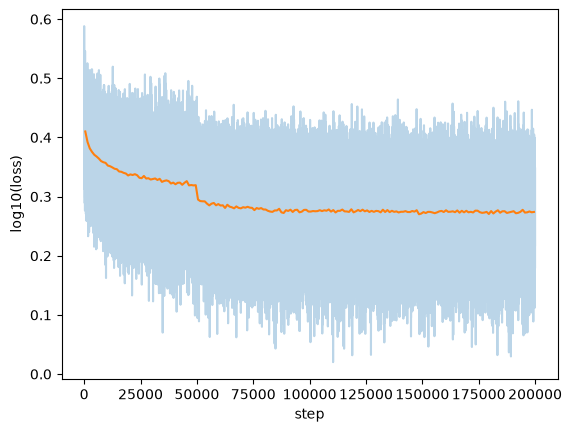

 # block embd hidden batch   steps                                                 lr                                                lam       seed   train     dev
 0     6   50    500    32  200000  [(0, 0.1), (50000, 0.01), (80000, 0.001), (150000, 0.0001)]  0.0001   24032608  1.7967  1.9776


In [4]:
# Evaluation, graphe et comparaison

tr, dv = split_loss(Xtr, Ytr), split_loss(Xdev, Ydev)
runs.append(dict(block=block_size, embd=n_embd, hidden=n_hidden, batch=batch_size,
                 steps=max_steps, lr=str(lr_sched), lam=lam, seed=seed, train=tr, dev=dv))

k = 1000
smooth = torch.tensor(lossi[:len(lossi) // k * k]).view(-1, k).mean(1)
plt.plot(lossi, alpha=0.3)
plt.plot(torch.arange(len(smooth)) * k + k // 2, smooth)
plt.xlabel('step'); plt.ylabel('log10(loss)')
plt.show()

print(f"{'#':>2} {'block':>5} {'embd':>4} {'hidden':>6} {'batch':>5} {'steps':>7} {'lr':>50} {'lam':>50} {'seed':>10} {'train':>7} {'dev':>7}")
for j, r in enumerate(runs):
	print(f"{j:>2} {r['block']:>5} {r['embd']:>4} {r['hidden']:>6} {r['batch']:>5} {r['steps']:>7} {r['lr']:>60} {r['lam']:>7} {r['seed']:>10} {r['train']:>7.4f} {r['dev']:>7.4f}")

In [5]:
# TEST FINAL
split_loss(Xte, Yte)

1.9743049144744873

In [6]:
# ÉCHANTILLONNAGE
g_s = torch.Generator().manual_seed(seed + 10)

for _ in range(20):
	out = []
	context = [0] * block_size
	while True:
		with torch.no_grad():
			emb = C[torch.tensor([context])]
			h = torch.tanh(emb.view(1, -1) @ W1 + b1)
			probs = F.softmax(h @ W2 + b2, dim=1)
		ix = torch.multinomial(probs, num_samples=1, generator=g_s).item()
		context = context[1:] + [ix]
		if ix == 0:
			break
		out.append(itos[ix])
	print(''.join(out))

kathran
ruhmina
milian
vikaya
zeyan
tajen
nyala
nicolzi
garchelle
holdyn
bricer
hulein
brianna
azeri
ibuchian
janvij
saroda
dovano
neyan
fyochim
